# Compositional Analysis 0 - Analysis

## Introduction

Here the analysis of the deconvolution results from lung samples is performed by conducting a compositional analysis across disease stages.

## Libraries

In [1]:
library(here)
library(glue)
library(tidyverse)
library(tidytext)
library(patchwork)
library(SpatialExperiment)
library(HDF5Array)
library(sccomp)
library(ggsignif)
library(svglite)

here() starts at /home/groups/singlecell/cvicente/SP-COVID/visium/2-analysis/COMP

── Attaching core tidyverse packages ──────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘matrixStats’


The following object is masked from ‘package:dplyr’:

    count



Attaching package

## Load data

In [2]:
spe <- loadHDF5SummarizedExperiment(dir = "~/SP-COVID/visium/0-processing/out/3-annot_lung_spe")
rownames(spatialCoords(spe)) <- paste(colData(spe)$cond_tissue, rownames(spatialCoords(spe)), sep = "_")
colnames(spe) <- paste(colData(spe)$cond_tissue, colnames(spe), sep = "_")
rowData(spe)$ensembl <- rownames(spe)
rownames(spe) <- rowData(spe)$gene_name

mat <- readRDS("~/SP-COVID/visium/1-deconvolution/out/mat_filtered_lung.rds")

In [3]:
meta <- as.data.frame(colData(spe)[, c("study_id", "disease_group")]) %>%
    rownames_to_column("spot_id")
meta$stage <- meta$disease_group
meta$disease_group <- NULL

compositions <- mat %>%
    as.data.frame() %>%
    rownames_to_column("spot_id") %>%
    left_join(meta, by = "spot_id") %>%
    pivot_longer(cols = -c(spot_id, study_id, stage),
                 names_to = "cell_group", values_to = "fraction") %>%
    group_by(sample = study_id, stage, cell_group) %>%
    summarise(proportion = mean(fraction, na.rm = TRUE),
              n_spots = n(), .groups = "drop") %>%
    mutate(stage = factor(stage,
                                  levels = c("control", "acute", "chronic", "prolonged"))) 

head(meta)
head(compositions)

,spot_id,study_id,stage
,<chr>,<chr>,<chr>
1,control_case_1-lung_AAACAAGTATCTCCCA-1,control_case_1,control
2,control_case_1-lung_AAACACCAATAACTGC-1,control_case_1,control
3,control_case_1-lung_AAACAGAGCGACTCCT-1,control_case_1,control
4,control_case_1-lung_AAACAGTGTTCCTGGG-1,control_case_1,control
5,control_case_1-lung_AAACATTTCCCGGATT-1,control_case_1,control
6,control_case_1-lung_AAACCCGAACGAAATC-1,control_case_1,control


sample,stage,cell_group,proportion,n_spots
<chr>,<fct>,<chr>,<dbl>,<int>
acute_case_1,acute,AT1,0.12361536,1877
acute_case_1,acute,AT2,0.02124347,1877
acute_case_1,acute,AdvF,0.09530673,1877
acute_case_1,acute,Aerocytes,0.11797299,1877
acute_case_1,acute,AlvF,0.10749870,1877
acute_case_1,acute,Anti-inflammatory Macrophages,0.01411718,1877


## Model the deconvolution proportions

Cell type compositional differences across disease groups will be estimated using `sccomp`, a Bayesian mixed-effects model based on a sum-constrained Beta-binomial distribution.  For each cell type, we will model the mean proportion as a function of disease group (`~ 0 + disease_group`), without setting any reference level (intercept = 0) to be able to perform different contrasts. Model fitting will be performed via `sccomp_estimate()`, and we will test posterior contrasts using `sccomp_test()` with a minimum effect size threshold of 0.1 on the logit scale to focus on biologically meaningful compositional shifts. This threshold filters associations that, while statistically credible, represent negligible changes in cell type proportion.

In [4]:
sccomp_fit <- compositions |>
    sccomp_estimate(formula_composition = ~ 0 + stage,
                    sample = "sample",
                    cell_group = "cell_group",
                    abundance = "proportion",
                    cores = 6,
                    verbose = TRUE,
                    output_directory = "out/sccomp_draws_files",
                    mcmc_seed = 42)

sccomp_res <- sccomp_fit |>
    sccomp_test(contrasts =  c("stageacute - stagecontrol", 
                               "stagechronic - stageacute", 
                               "stageprolonged - stagechronic", 
                               "stageprolonged - stageacute"))

sccomp says: proportion column is a proportion. The sum-constrained beta model will be used. When possible using counts is preferred as the binomial noise component is often dominating for rare groups (e.g. rare cell types).

sccomp says: estimation

sccomp says: the composition design matrix has columns: stagecontrol, stageacute, stagechronic, stageprolonged

sccomp says: the variability design matrix has columns: (Intercept)

Loading model from cache...

Warning message in fit_model(., "glm_multi_beta_binomial", cores = cores, quantile = CI, :
“sccomp says: your proportion values include 0. Assuming that 0s derive from a precision threshold (e.g. deconvolution), 0s are converted to the smaller non 0 proportion value.”


Path [13] :Initial log joint density = -23.650355Path [7] :Initial log joint density = -83.187066Path [26] :Initial log joint density = -458.712446 
Path [10] :Initial log joint density = -208.199140 
Path [4] :Initial log joint density = -89.829844 
Path [1] :Initial log joint density = -112.862054 
Path [13] : Iter      log prob        ||dx||      ||grad||     alpha      alpha0      # evals       ELBO    Best ELBO        Notes  
            100       7.928e+02      3.613e-02   4.437e+04    5.148e-02  5.148e-02      8968  5.901e+02 -1.505e+04                   
Path [13] :Best Iter: [8] ELBO (590.092665) evaluations: (8968) 
Path [26] : Iter      log prob        ||dx||      ||grad||     alpha      alpha0      # evals       ELBO    Best ELBO        Notes  
            100       7.773e+02      7.024e-02   9.888e+03    6.729e-02  6.729e-02      8731  5.918e+02 -2.570e+03                   
Path [26] :Best Iter: [15] ELBO (591.789662) evaluations: (8731) 
Path [14] :Initial log joint dens

sccomp says: to do hypothesis testing run `sccomp_test()`,
  the `test_composition_above_logit_fold_change` = 0.1 equates to a change of ~10%, and
  0.7 equates to ~100% increase, if the baseline is ~0.1 proportion.
  Use `sccomp_proportional_fold_change` to convert c_effect (linear) to proportion difference (non-linear).



## Results analysis

### Differential cell type composition across disease groups

Posterior estimates of differential cell type composition for each stage contrast are shown below. For each cell type, the point estimate represents the mean composition effect (`c_effect`) on the logit scale, with horizontal error bars spanning the 95% posterior credible interval. Effects are coloured by statistical significance (FDR < 0.05, Benjamini–Hochberg corrected): red indicates significant compositional shifts, grey indicates non-significant associations. Dashed vertical lines at ±0.05 denote the region of negligible effect. Results are shown for each contrast, showing compositional changes progressive to disease stage.

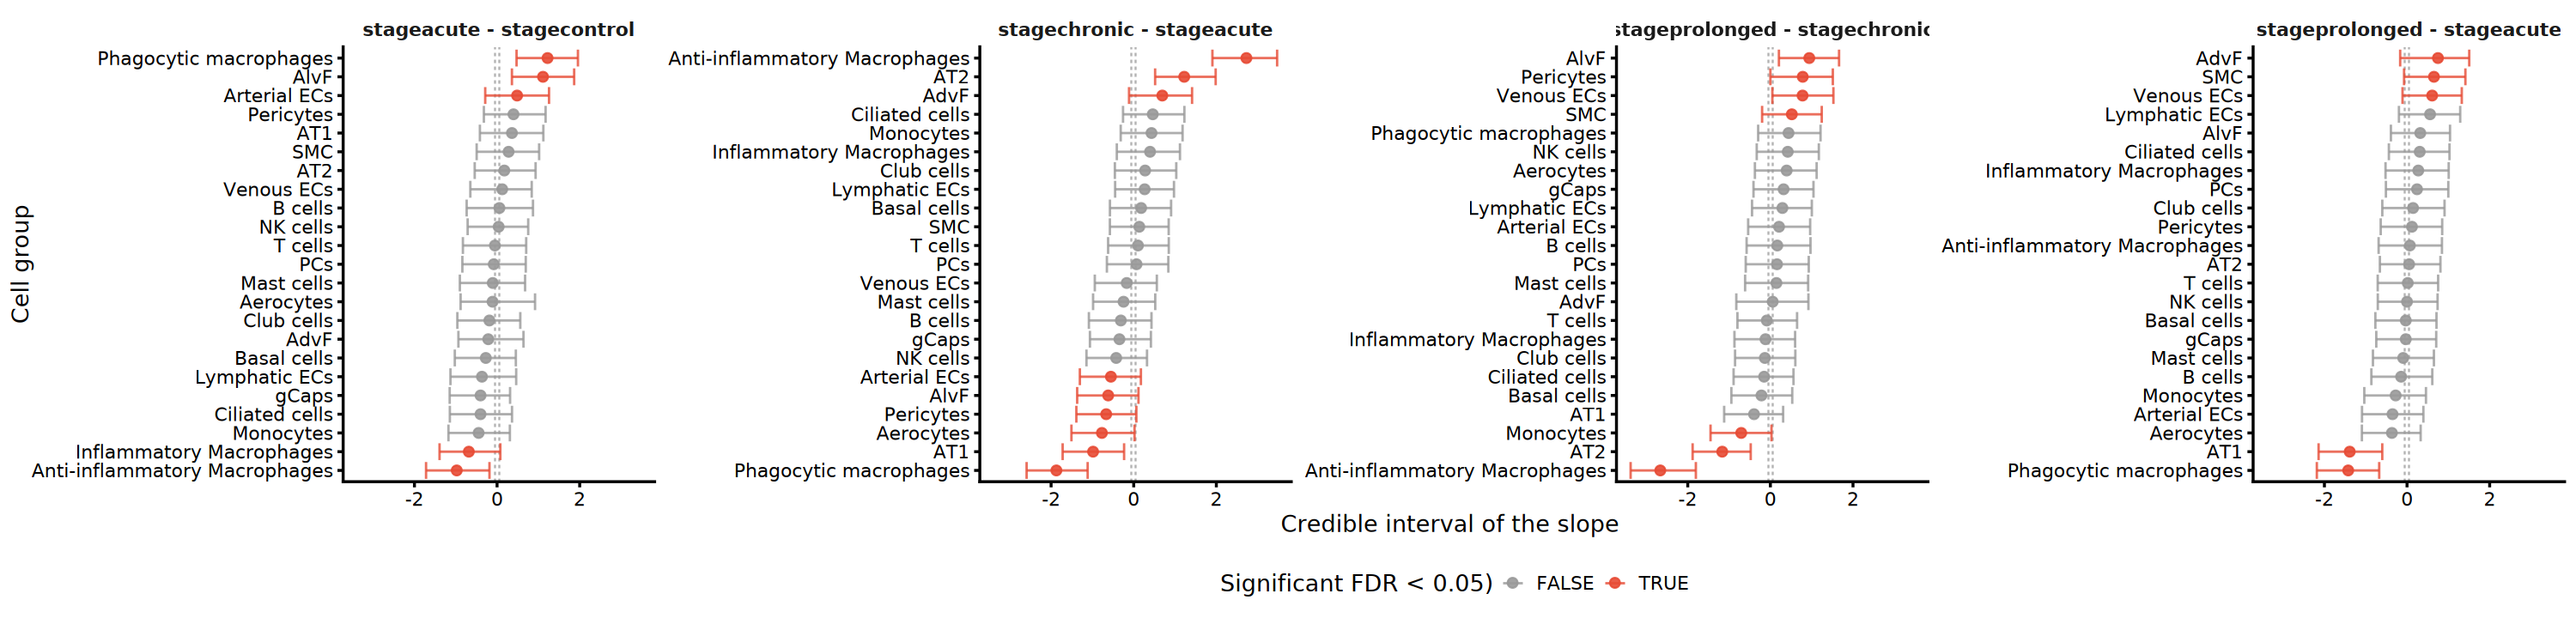

In [5]:
options(repr.plot.width = 25, repr.plot.height = 6, warn = -1)

p <- sccomp_res %>%
    mutate(sig = c_FDR < 0.05, 
           parameter = factor(parameter, levels = c("stageacute - stagecontrol", 
                                                    "stagechronic - stageacute", 
                                                    "stageprolonged - stagechronic", 
                                                    "stageprolonged - stageacute")),
           cell_group = reorder_within(cell_group, c_effect, parameter)) %>% 
    ggplot(aes(x = c_effect, y = cell_group, color = sig)) +
    geom_vline(xintercept = 0.05, linetype = "dashed", color = "grey70", linewidth = 0.5) +
    geom_vline(xintercept = -0.05, linetype = "dashed", color = "grey70", linewidth = 0.5) +
    geom_errorbarh(aes(xmin = c_lower, xmax = c_upper), 
                   heigwidhtht = 0.3, linewidth = 0.6, alpha = 0.8) +
    geom_point(size = 2.5, alpha = 0.9) +
    facet_wrap(~ parameter, scales = "free_y", ncol = 4) +
    scale_y_reordered() + 
    scale_color_manual(values = c("TRUE" = "#E64B35", "FALSE" = "#999999")) +
    labs(x = "Credible interval of the slope ",
         y = "Cell group", 
         color = "Significant FDR < 0.05)") +
    theme_classic(base_size = 16) +
    theme(strip.background = element_rect(fill = "white", color = NA),
          strip.text = element_text(face = "bold"),
          legend.position = "bottom",
          panel.spacing.x = unit(1, "lines"))
ggsave("out/plots/intervals1d_lung_comp.svg", plot = p, device = svglite, width = 25, height = 6)
print(p)

In [6]:
predicted <- sccomp_predict(sccomp_fit, formula_composition = ~ 0 + stage, mcmc_seed = 42)
stage_levels <- c("control", "acute", "chronic", "prolonged")
x_pos <- setNames(seq_along(stage_levels), stage_levels)
width <- 0.35

predicted <- predicted %>%
    mutate(x = x_pos[as.character(stage)],
           xmin = x - width,
           xmax = x + width)
sig_annotations <- sccomp_res %>%
    filter(c_FDR < 0.05) %>%
    mutate(group1 = case_when(startsWith(parameter, "stageacute - stagecontrol") ~ "control",
                              startsWith(parameter, "stagechronic - stageacute") ~ "acute",
                              startsWith(parameter, "stageprolonged - stagechronic") ~ "chronic",
                              startsWith(parameter, "stageprolonged - stageacute") ~ "acute"),
           group2 = case_when(startsWith(parameter, "stageacute - stagecontrol") ~ "acute",
                              startsWith(parameter, "stagechronic - stageacute") ~ "chronic",
                              startsWith(parameter, "stageprolonged - stagechronic") ~ "prolonged",
                              startsWith(parameter, "stageprolonged - stageacute") ~ "prolonged"),
           label = ifelse(c_FDR < 0.001, "***",
                          ifelse(c_FDR < 0.01,  "**", "*"))) %>%
    select(cell_group, group1, group2, label) %>%
    left_join(compositions %>%
              group_by(cell_group) %>%
              summarise(max_prop = max(proportion), .groups = "drop"),
              by = "cell_group") %>%
    group_by(cell_group) %>%
    mutate(y_position = max_prop * (1.05 + 0.08 * (row_number() - 1))) %>%
    ungroup()

Loading model from cache...



Running standalone generated quantities after 1 MCMC chain, with 1 thread(s) per chain...

Chain 1 finished in 0.0 seconds.


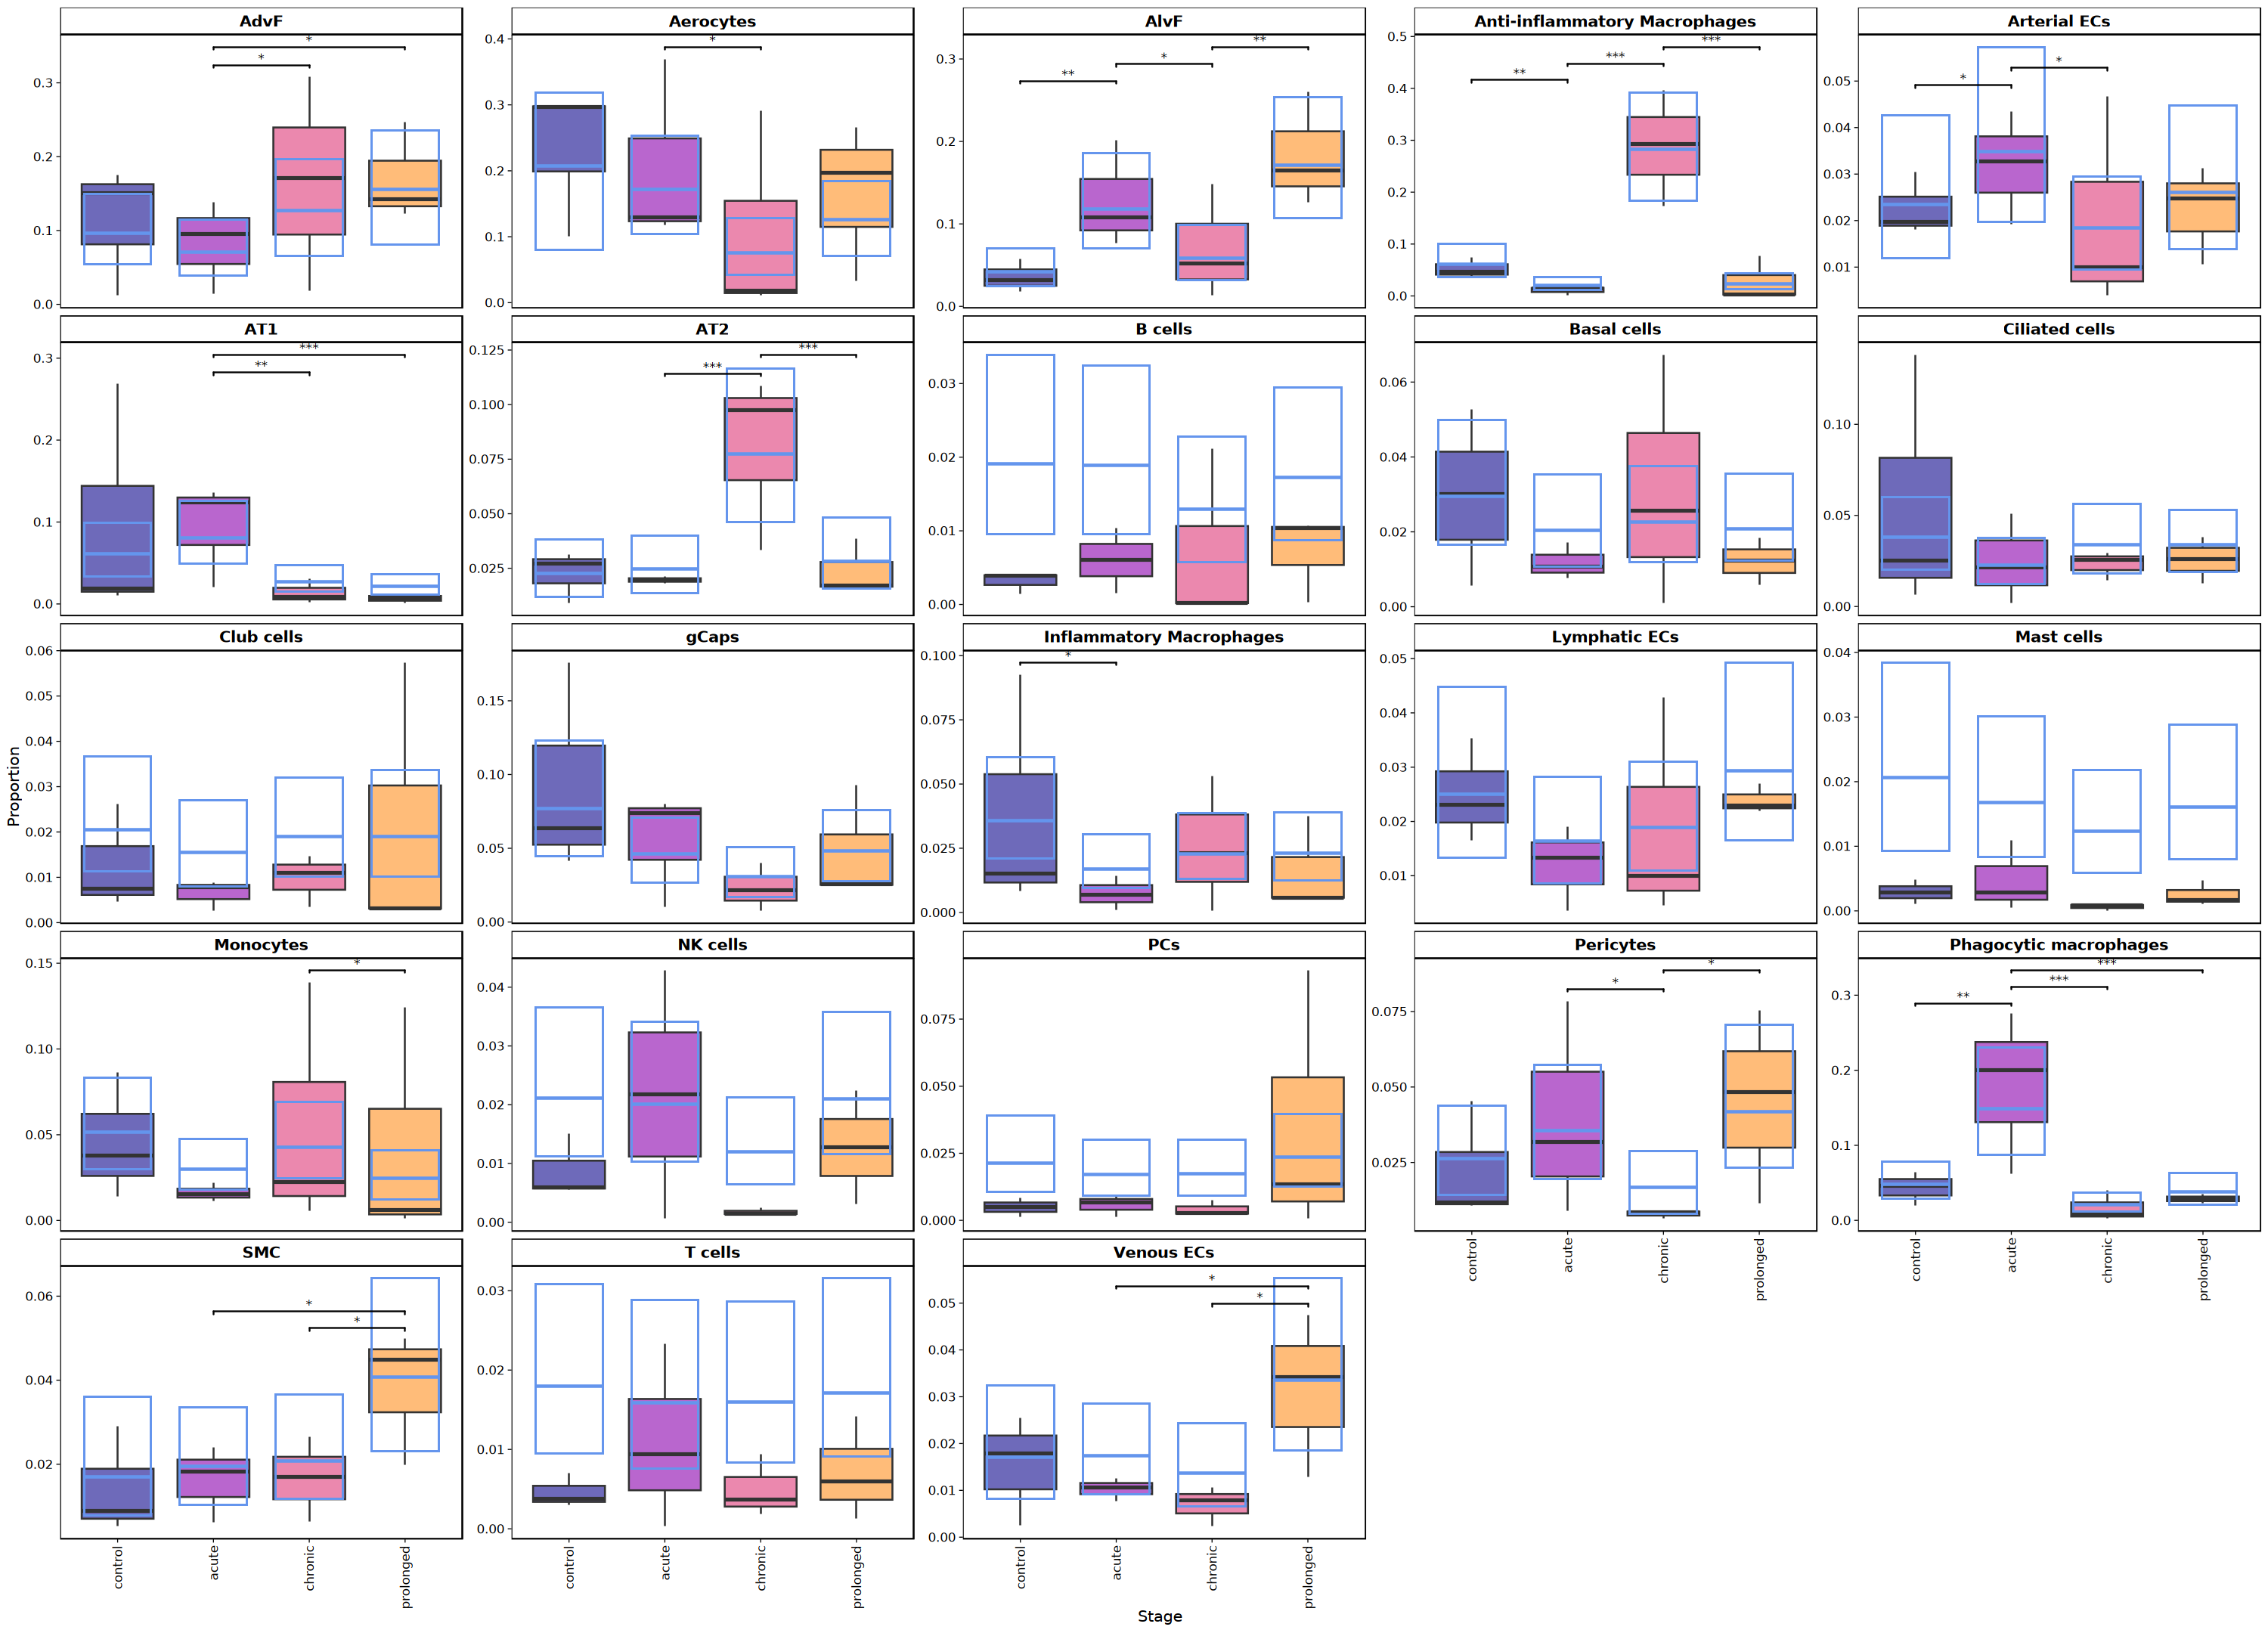

In [7]:
options(repr.plot.width = 25, repr.plot.height = 18, warn = -1)

p <- compositions %>%
    ggplot(aes(x = stage, y = proportion, fill = stage)) +
    geom_boxplot(alpha = 0.6, outlier.size = 0.5) +
    geom_rect(data = predicted,
              aes(xmin = xmin, xmax = xmax,
                  ymin = proportion_lower, ymax = proportion_upper),
              inherit.aes = FALSE,
              fill = NA, color = "cornflowerblue", linewidth = 0.6) +
    geom_segment(data = predicted,
                 aes(x = xmin, xend = xmax,
                     y = proportion_mean, yend = proportion_mean),
                 inherit.aes = FALSE,
                 color = "cornflowerblue", linewidth = 0.8) +
    geom_signif(data = sig_annotations,
                aes(xmin = group1, xmax = group2,
                    annotations = label, y_position = y_position),
                manual = TRUE,
                inherit.aes = FALSE,
                tip_length = 0.01,
                textsize = 3.5) +
    facet_wrap(~ cell_group, scales = "free_y") +
    scale_x_discrete(limits = c("control", "acute", "chronic", "prolonged")) +
    scale_fill_manual(values = c("control" = "#0E088D", "acute" = "#8A00AE",
                                 "chronic" = "#DD3978", "prolonged" = "#FF8F20")) +
    labs(x = "Stage", y = "Proportion", fill = "") +
    theme_linedraw(base_size = 12) +

    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
          strip.text = element_text(face = "bold", size = 12, color = "black"),
          strip.background = element_rect(fill = "white", color = "black"),
          panel.grid = element_blank(),
          legend.position = "none")
ggsave("out/plots/boxplots_predicted_lung_comp.svg", plot = p, device = svglite, width = 25, height = 18)
print(p)

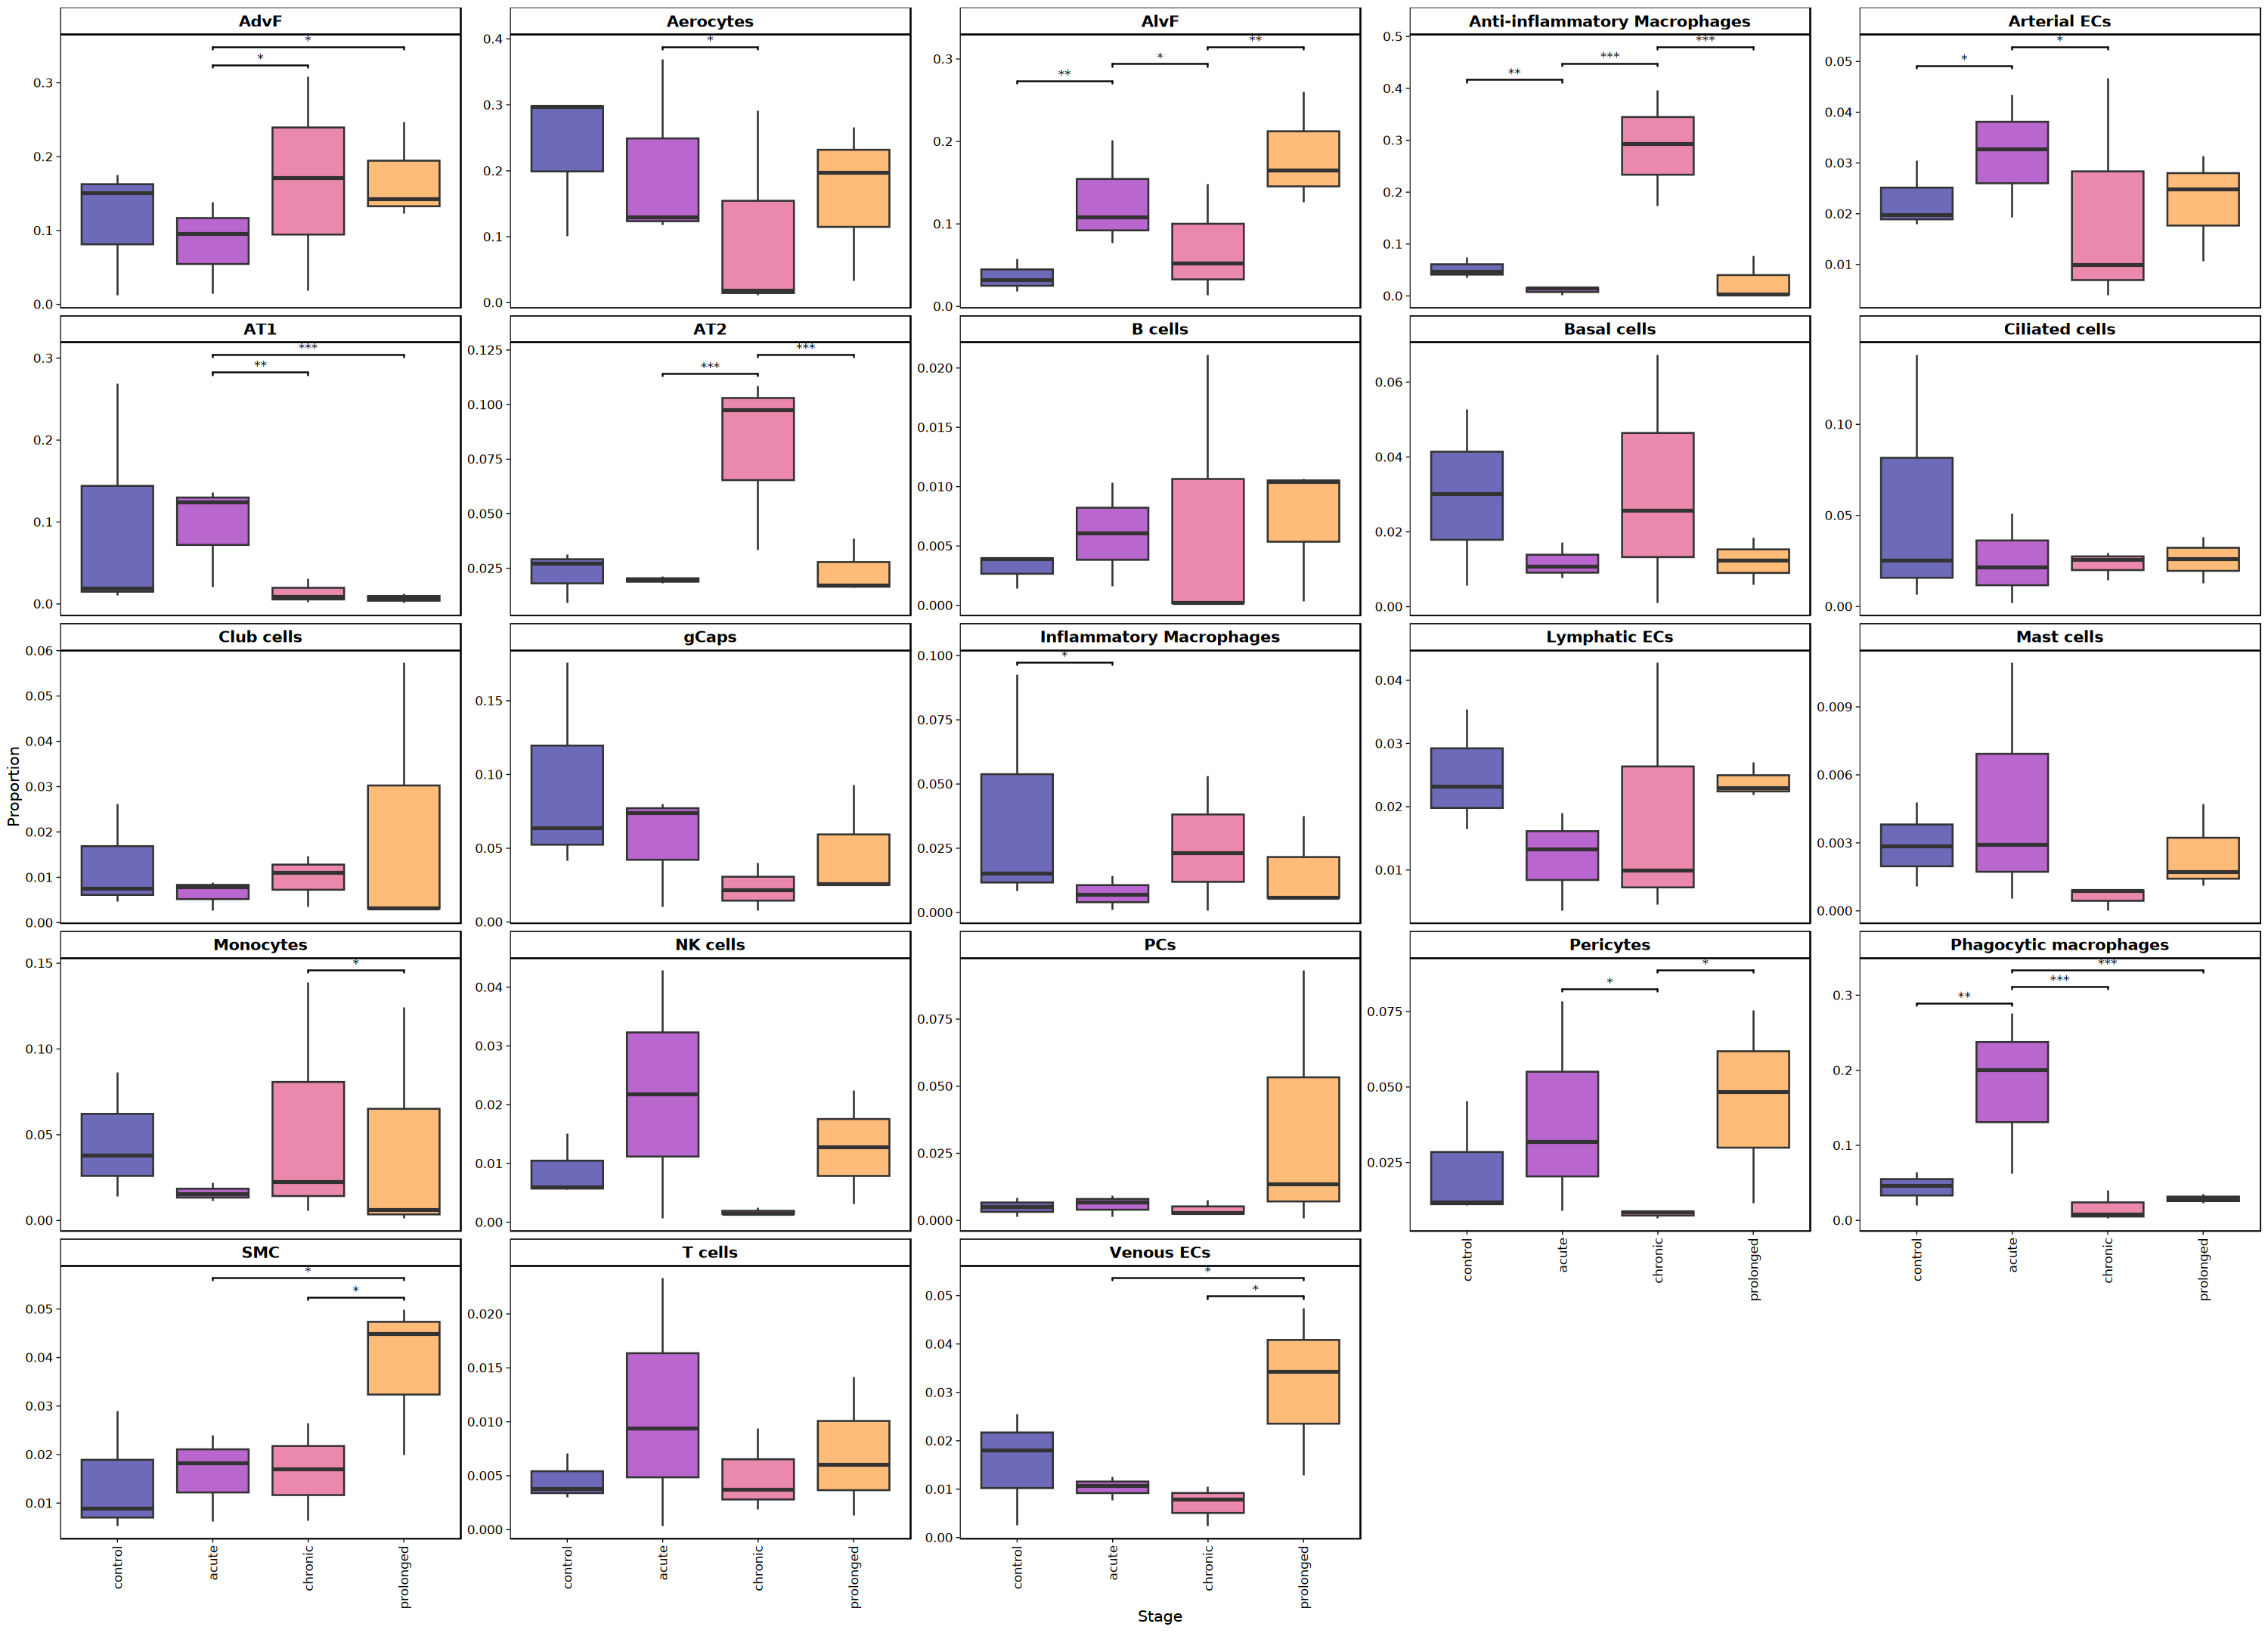

In [8]:
p <- compositions %>%
    ggplot(aes(x = stage, y = proportion, fill = stage)) +
    geom_boxplot(alpha = 0.6, outlier.size = 0.5) +
    geom_signif(data = sig_annotations,
                aes(xmin = group1, xmax = group2,
                    annotations = label, y_position = y_position),
                manual = TRUE,
                inherit.aes = FALSE,
                tip_length = 0.01,
                textsize = 3.5) +
    facet_wrap(~ cell_group, scales = "free_y") +
    scale_x_discrete(limits = c("control", "acute", "chronic", "prolonged")) +
    scale_fill_manual(values = c("control" = "#0E088D", "acute" = "#8A00AE",
                                 "chronic" = "#DD3978", "prolonged" = "#FF8F20")) +
    labs(x = "Stage", y = "Proportion", fill = "") +
    theme_linedraw(base_size = 12) +

    theme(axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1),
          strip.text = element_text(face = "bold", size = 12, color = "black"),
          strip.background = element_rect(fill = "white", color = "black"),
          panel.grid = element_blank(),
          legend.position = "none")
ggsave("out/plots/boxplots_lung_comp.svg", plot = p, device = svglite, width = 25, height = 18)
print(p)

### Proportional fold changes relative to control

To quantify the magnitude of compositional shifts on the proportion scale, we will compute proportional fold changes for each cell type across all the contrasts using `sccomp_proportional_fold_change()`. Unlike the logit-scale effects estimated during model fitting, proportional fold changes express compositional differences as ratios of cell type proportions, offering a more directly interpretable measure of effect size.

> The fold changes are derived from the model's posterior predictions rather than raw counts, providing a more robust estimate that accounts for the model's uncertainty and covariate effects.


In [9]:
comps <- tibble::tibble(from = c("control", "acute", "chronic", "acute"),
                        to = c("acute", "chronic", "prolonged", "prolonged"))

fc <-  purrr::pmap_dfr(comps, function(from, to) {
    sccomp_res |> 
    sccomp_proportional_fold_change(formula_composition = ~ 0 + stage, from = from, to = to) |>
    mutate(from = from, to = to)}) |>
left_join(sccomp_res %>% 
          mutate(from = sub("stage(\\w+) - stage(\\w+)", "\\2", parameter),
                 to = sub("stage(\\w+) - stage(\\w+)", "\\1", parameter)) %>%
          select(cell_group, from, to, c_FDR), by = c("cell_group", "from", "to")) |>
mutate(significance = case_when(c_FDR < 0.001 ~ "***",
                                c_FDR < 0.01 ~ "**",
                                c_FDR < 0.05 ~ "*",
                                TRUE ~ "")) |>
select(cell_group, from, to, proportion_fold_change, c_FDR, significance, statement)

Loading model from cache...



Running standalone generated quantities after 1 MCMC chain, with 1 thread(s) per chain...

Chain 1 finished in 0.0 seconds.


Loading model from cache...



Running standalone generated quantities after 1 MCMC chain, with 1 thread(s) per chain...

Chain 1 finished in 0.0 seconds.


Loading model from cache...



Running standalone generated quantities after 1 MCMC chain, with 1 thread(s) per chain...

Chain 1 finished in 0.0 seconds.


Loading model from cache...



Running standalone generated quantities after 1 MCMC chain, with 1 thread(s) per chain...

Chain 1 finished in 0.0 seconds.


In [10]:
options(width = 200)  

fc %>%
    select(cell_group, from, to, proportion_fold_change, c_FDR) %>% 
    print(n = Inf, width = Inf)

# A tibble: 92 × 5
   cell_group                    from    to        proportion_fold_change    c_FDR
   <chr>                         <chr>   <chr>                      <dbl>    <dbl>
 1 AdvF                          control acute                      -1.36 0.185   
 2 Aerocytes                     control acute                      -1.22 0.243   
 3 AlvF                          control acute                       2.74 0.00337 
 4 Anti-inflammatory Macrophages control acute                      -2.80 0.00708 
 5 Arterial ECs                  control acute                       1.49 0.049   
 6 AT1                           control acute                       1.26 0.130   
 7 AT2                           control acute                       1.10 0.213   
 8 B cells                       control acute                      -1.02 0.283   
 9 Basal cells                   control acute                      -1.41 0.156   
10 Ciliated cells                control acute                      

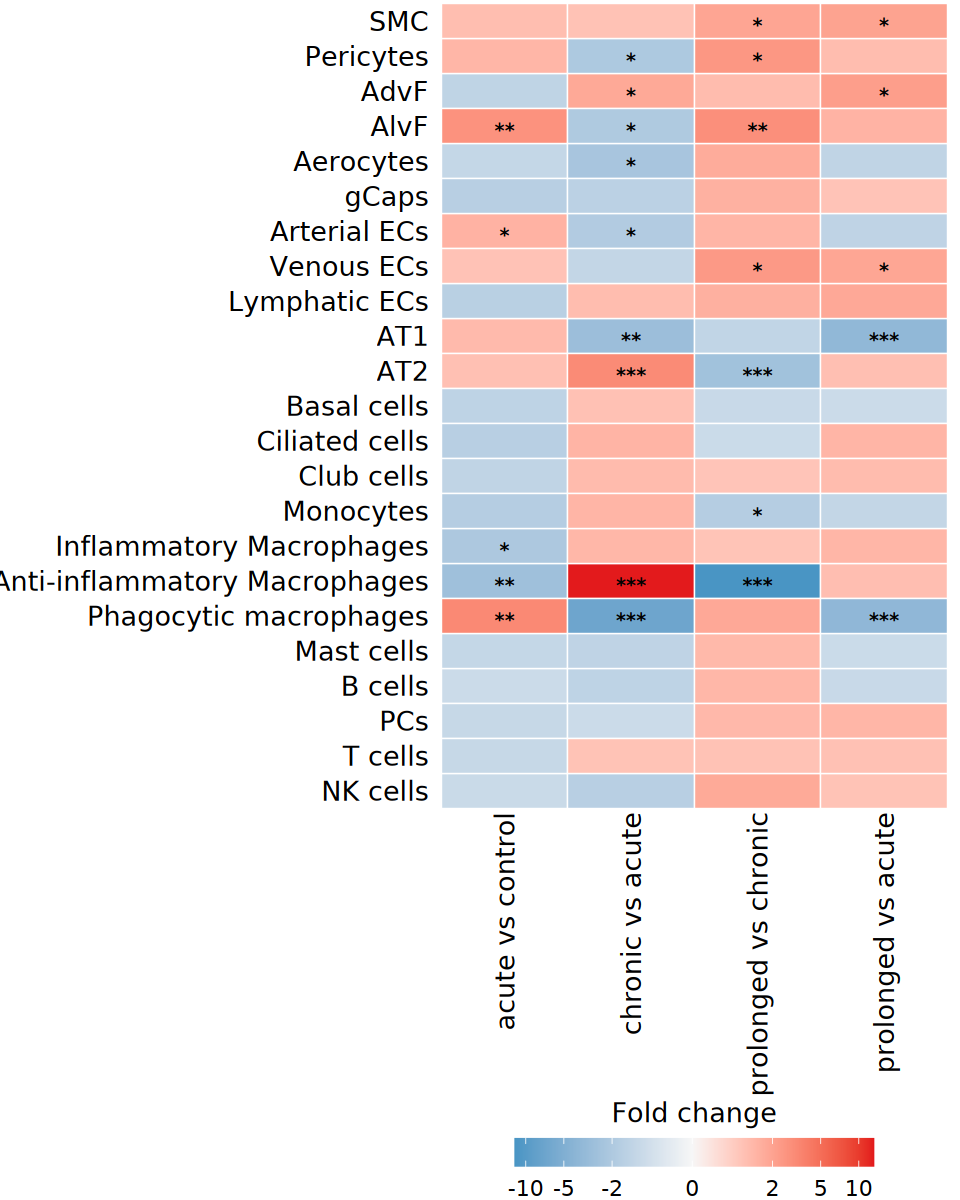

In [11]:
options(repr.plot.width = 8, repr.plot.height = 10, warn = -1)

ct <- c("SMC", "Pericytes", "AdvF", "AlvF",
        "Aerocytes", "gCaps", "Arterial ECs", "Venous ECs", "Lymphatic ECs",
        "AT1", "AT2", "Basal cells", "Ciliated cells", "Club cells",
        "Monocytes", "Inflammatory Macrophages", "Anti-inflammatory Macrophages", "Phagocytic macrophages",
        "Mast cells", "B cells", "PCs", "T cells", "NK cells")

fc <- fc %>%
    mutate(contrast = paste0(to, " vs ", from))

p <- ggplot(fc, aes(x = contrast, y = cell_group, fill = proportion_fold_change)) +
    geom_tile(color = "white", linewidth = 0.3) +
    scale_x_discrete(limits = c("acute vs control", "chronic vs acute", 
                                "prolonged vs chronic", "prolonged vs acute")) +
    scale_y_discrete(limits = rev(ct)) +
    geom_text(data = fc %>% filter(significance != ""),
              aes(x = contrast, y = cell_group, label = significance),
              size = 4, fontface = "bold", color = "black",
              vjust = 0.75, hjust = 0.5, inherit.aes = FALSE) +
    scale_fill_gradient2(low = "#4393C3", mid = "#F7F7F7", high = "#E31A1C",
                         midpoint = 0, trans = scales::pseudo_log_trans(sigma = 0.5),  
                         breaks = c(-10, -5, -2, 0, 2, 5, 10), name = "Fold change") +
    labs(x = "", y = "") +
    theme_void(base_size = 16) +
    theme(axis.text.y = element_text(hjust = 1),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
          legend.position = "bottom") +
    guides(fill = guide_colorbar(title.position = "top", title.hjust = 0.5, barwidth = 15))

ggsave("out/plots/heatmap_lung_comp.svg", plot = p, device = svglite, width = 8, height = 10)
print(p)

# Session information

In [12]:
sessionInfo()

R version 4.5.2 (2025-10-31)
Platform: x86_64-conda-linux-gnu
Running under: CentOS Linux 7 (Core)

Matrix products: default
BLAS/LAPACK: /home/groups/singlecell/cvicente/miniconda3/envs/COVID/lib/libopenblasp-r0.3.30.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C               LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8     LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8    LC_PAPER=en_US.UTF-8      
 [8] LC_NAME=C                  LC_ADDRESS=C               LC_TELEPHONE=C             LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Madrid
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] svglite_2.2.2               ggsignif_0.6.4              sccomp_2.2.0                instantiate_0.2.3           HDF5Array_1.38.0            h5mread_1.2.1               rhdf5_2.54.1               
 [8] DelayedArray_0.